<a href="https://colab.research.google.com/github/zaid18-PU/InternSpark-Task-3/blob/main/InternSpark3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

data_dir = 'data/'  # place the 7 CSVs from the Kaggle download in this folder

users      = pd.read_csv(data_dir + 'users.csv')
photos     = pd.read_csv(data_dir + 'photos.csv')
likes      = pd.read_csv(data_dir + 'likes.csv')
comments   = pd.read_csv(data_dir + 'comments.csv')
follows    = pd.read_csv(data_dir + 'follows.csv')
tags       = pd.read_csv(data_dir + 'tags.csv')
photo_tags = pd.read_csv(data_dir + 'photo_tags.csv')

# strip stray whitespace from column headers (present in the raw export)
for df in [users, photos, likes, comments, follows, tags, photo_tags]:
    df.columns = [c.strip() for c in df.columns]

print("Tables loaded:")
for name, df in [('users',users),('photos',photos),('likes',likes),('comments',comments),
                  ('follows',follows),('tags',tags),('photo_tags',photo_tags)]:
    print(f"  {name:12s} {df.shape[0]:>5} rows x {df.shape[1]} cols")


Tables loaded:
  users          100 rows x 6 cols
  photos         257 rows x 6 cols
  likes         8782 rows x 5 cols
  comments      7488 rows x 8 cols
  follows       7623 rows x 5 cols
  tags            21 rows x 4 cols
  photo_tags     501 rows x 3 cols


In [ ]:

for name, df in [('users',users),('photos',photos),('likes',likes),('comments',comments),
                  ('follows',follows),('tags',tags),('photo_tags',photo_tags)]:
    print(f"--- {name} ---")
    print(df.dtypes.to_string())
    print()


--- users ---
id                 int64
name                 str
created time         str
private/public       str
post count         int64
Verified status      str

--- photos ---
id                   int64
image link             str
user ID              int64
created dat            str
Insta filter used      str
photo type             str

--- likes ---
user                int64
photo               int64
created time          str
following or not      str
like type             str

--- comments ---
id                     int64
comment                  str
User  id               int64
Photo id               int64
created Timestamp        str
posted date              str
emoji used               str
Hashtags used count    int64

--- follows ---
follower               int64
followee               int64
created time             str
is follower active     int64
followee Acc status      str

--- tags ---
id              int64
tag text          str
created time      str
location          str

In [ ]:

users.head()


In [ ]:

photos.head()


In [ ]:

missing = {name: int(df.isnull().sum().sum()) for name, df in
           [('users',users),('photos',photos),('likes',likes),('comments',comments),
            ('follows',follows),('tags',tags),('photo_tags',photo_tags)]}
pd.Series(missing, name='missing_cells')


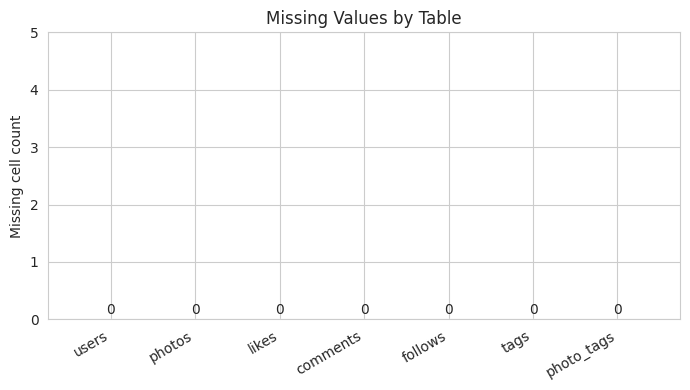

In [ ]:

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(missing.keys(), missing.values(), color='#3b7dd8')
ax.set_ylabel('Missing cell count')
ax.set_title('Missing Values by Table')
ax.set_ylim(0, 5)
for i,(k,v) in enumerate(missing.items()):
    ax.text(i, v + 0.1, str(v), ha='center')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


In [ ]:

users.describe(include='all').T


In [ ]:

photos['photo type'].value_counts()


In [ ]:

print("photos['created dat'] unique values:      ", photos['created dat'].nunique())
print("comments['created Timestamp'] unique:     ", comments['created Timestamp'].nunique())
print("comments['posted date'] unique:           ", comments['posted date'].nunique())
print("likes['created time'] unique:             ", likes['created time'].nunique())
print("follows['created time'] unique:           ", follows['created time'].nunique())
print("tags['created time'] unique:              ", tags['created time'].nunique())
print()
print("users['created time'] unique:             ", users['created time'].nunique(), " <- this one DOES vary")


photos['created dat'] unique values:       1
comments['created Timestamp'] unique:      1
comments['posted date'] unique:            1
likes['created time'] unique:              1
follows['created time'] unique:            1
tags['created time'] unique:               1

users['created time'] unique:              100  <- this one DOES vary


In [ ]:

users_r      = users.rename(columns={'id':'user_id'})
photos_r     = photos.rename(columns={'id':'photo_id','user ID':'user_id'})
likes_r      = likes.rename(columns={'user':'user_id','photo':'photo_id'})
comments_r   = comments.rename(columns={'User  id':'user_id','Photo id':'photo_id'})
photo_tags_r = photo_tags.rename(columns={'tag ID':'tag_id','user id':'user_id'})

# --- follower / following counts per user ---
followers_count = follows.groupby('followee').size().rename('followers_count')
following_count = follows.groupby('follower').size().rename('following_count')
users_r = users_r.set_index('user_id').join(followers_count).join(following_count).reset_index()
users_r['followers_count'] = users_r['followers_count'].fillna(0).astype(int)
users_r['following_count'] = users_r['following_count'].fillna(0).astype(int)
users_r['created time'] = pd.to_datetime(users_r['created time'], dayfirst=True, errors='coerce')

# --- post-level engagement ---
likes_per_photo    = likes_r.groupby('photo_id').size().rename('likes_count')
comments_per_photo = comments_r.groupby('photo_id').size().rename('comments_count')
avg_hashtags       = comments_r.groupby('photo_id')['Hashtags used count'].mean().rename('avg_hashtags_in_comments')

photos_full = (photos_r.set_index('photo_id')
               .join(likes_per_photo).join(comments_per_photo).join(avg_hashtags)
               .reset_index())
photos_full['likes_count']    = photos_full['likes_count'].fillna(0).astype(int)
photos_full['comments_count'] = photos_full['comments_count'].fillna(0).astype(int)
photos_full['total_engagement'] = photos_full['likes_count'] + photos_full['comments_count']

photos_full = photos_full.merge(
    users_r[['user_id','followers_count','private/public','Verified status']],
    on='user_id', how='left'
)
# engagement rate = (likes + comments) / followers of the posting account
photos_full['engagement_rate'] = photos_full['total_engagement'] / photos_full['followers_count'].replace(0, np.nan)

print(f"photos_full: {photos_full.shape[0]} posts x {photos_full.shape[1]} features")
photos_full[['photo_id','photo type','likes_count','comments_count','total_engagement',
             'followers_count','engagement_rate']].head()


photos_full: 257 posts x 14 features


In [ ]:

# tag popularity table
tag_counts = photo_tags_r.groupby('tag_id').size().rename('usage_count').reset_index()
tag_counts = tag_counts.merge(tags.rename(columns={'id':'tag_id'}), on='tag_id')
tag_counts.sort_values('usage_count', ascending=False).head(10)[['tag text','location','usage_count']]


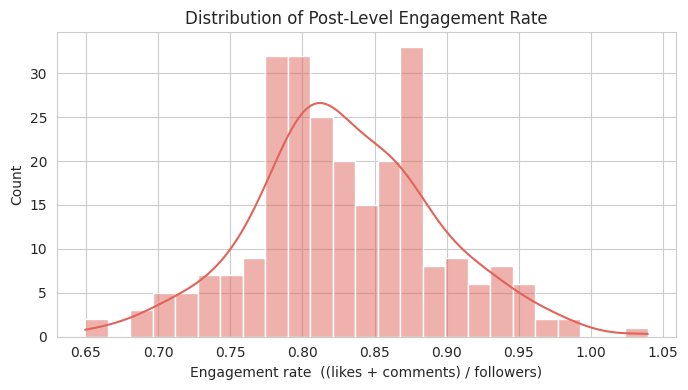

In [ ]:

fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(photos_full['engagement_rate'].dropna(), bins=25, kde=True, color='#e0645a', ax=ax)
ax.set_xlabel('Engagement rate  ((likes + comments) / followers)')
ax.set_title('Distribution of Post-Level Engagement Rate')
plt.tight_layout()
plt.show()


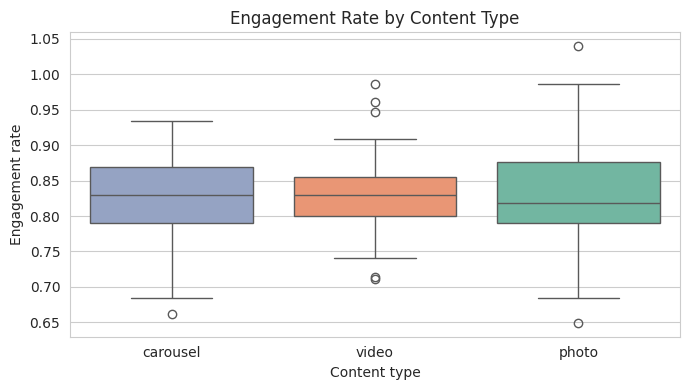

In [ ]:

fig, ax = plt.subplots(figsize=(7,4))
order = photos_full.groupby('photo type')['engagement_rate'].median().sort_values(ascending=False).index
sns.boxplot(data=photos_full, x='photo type', y='engagement_rate', order=order, hue='photo type', legend=False, palette='Set2', ax=ax)
ax.set_title('Engagement Rate by Content Type')
ax.set_xlabel('Content type'); ax.set_ylabel('Engagement rate')
plt.tight_layout()
plt.show()


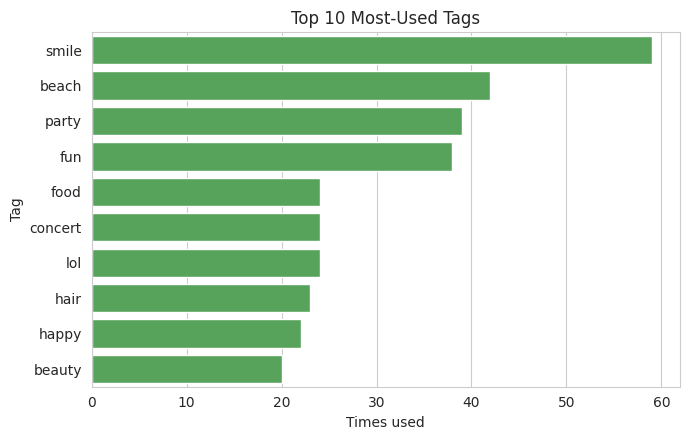

In [ ]:

top_tags = tag_counts.sort_values('usage_count', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(7,4.5))
sns.barplot(data=top_tags, y='tag text', x='usage_count', color='#4CAF50', ax=ax)
ax.set_title('Top 10 Most-Used Tags')
ax.set_xlabel('Times used'); ax.set_ylabel('Tag')
plt.tight_layout()
plt.show()


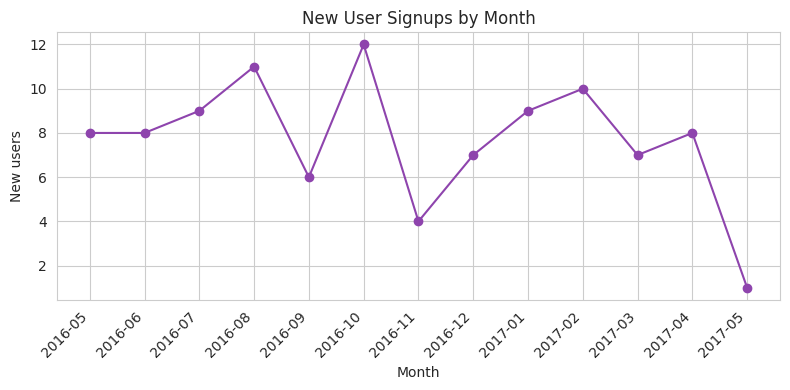

In [ ]:

signup_month = users_r['created time'].dt.to_period('M').value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(signup_month.index.astype(str), signup_month.values, marker='o', color='#8e44ad')
ax.set_title('New User Signups by Month')
ax.set_xlabel('Month'); ax.set_ylabel('New users')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


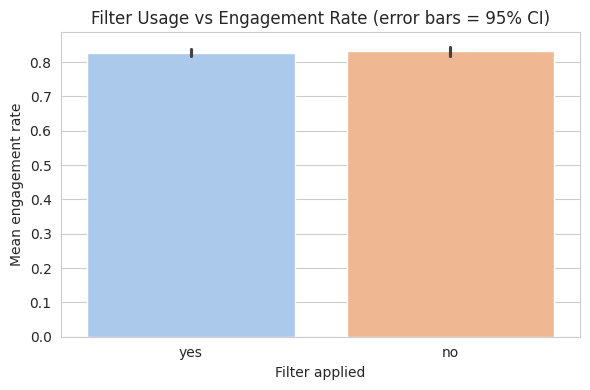

In [ ]:

fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(data=photos_full, x='Insta filter used', y='engagement_rate', errorbar='ci',
            hue='Insta filter used', legend=False, palette='pastel', ax=ax)
ax.set_title('Filter Usage vs Engagement Rate (error bars = 95% CI)')
ax.set_xlabel('Filter applied'); ax.set_ylabel('Mean engagement rate')
plt.tight_layout()
plt.show()


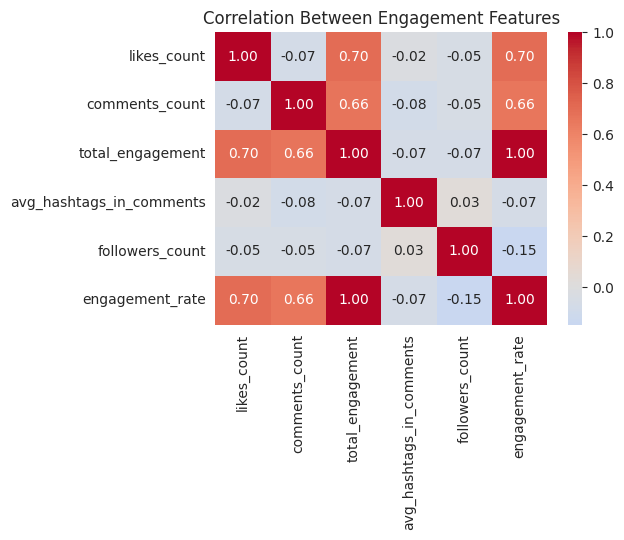

In [ ]:

corr_df = photos_full[['likes_count','comments_count','total_engagement',
                        'avg_hashtags_in_comments','followers_count','engagement_rate']].corr()
fig, ax = plt.subplots(figsize=(6.5,5.5))
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Between Engagement Features')
plt.tight_layout()
plt.show()


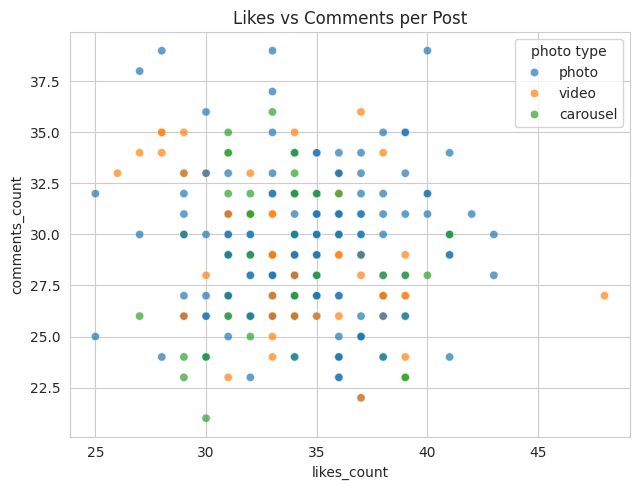

In [ ]:

fig, ax = plt.subplots(figsize=(6.5,5))
sns.scatterplot(data=photos_full, x='likes_count', y='comments_count', hue='photo type', ax=ax, alpha=0.7)
ax.set_title('Likes vs Comments per Post')
plt.tight_layout()
plt.show()


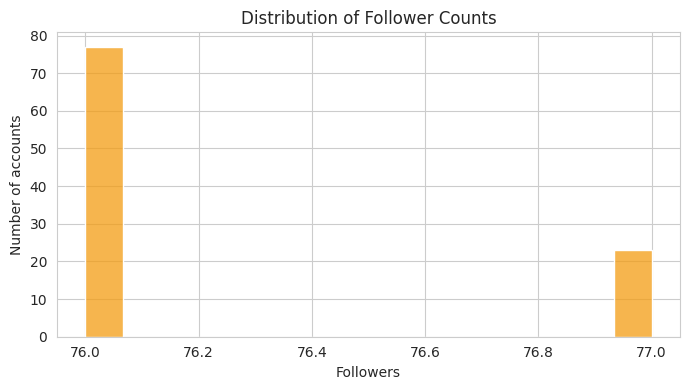

In [ ]:

fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(users_r['followers_count'], bins=15, color='#f39c12', ax=ax)
ax.set_title('Distribution of Follower Counts')
ax.set_xlabel('Followers'); ax.set_ylabel('Number of accounts')
plt.tight_layout()
plt.show()


In [ ]:

# Content type -> engagement rate (ANOVA)
groups = [g['engagement_rate'].dropna().values for _, g in photos_full.groupby('photo type')]
anova = stats.f_oneway(*groups)
print(f"Content type ANOVA:      F={anova.statistic:.3f}, p={anova.pvalue:.3f}")

# Filter used -> engagement rate (t-test)
a = photos_full.loc[photos_full['Insta filter used']=='yes', 'engagement_rate'].dropna()
b = photos_full.loc[photos_full['Insta filter used']=='no',  'engagement_rate'].dropna()
t = stats.ttest_ind(a, b)
print(f"Filter used t-test:      t={t.statistic:.3f}, p={t.pvalue:.3f}")

# Hashtag count -> engagement rate (Pearson correlation)
sub = photos_full.dropna(subset=['avg_hashtags_in_comments','engagement_rate'])
r = stats.pearsonr(sub['avg_hashtags_in_comments'], sub['engagement_rate'])
print(f"Hashtags vs engagement:  r={r.statistic:.3f}, p={r.pvalue:.3f}")

# Verified -> engagement rate (t-test)
a = photos_full.loc[photos_full['Verified status']=='yes', 'engagement_rate'].dropna()
b = photos_full.loc[photos_full['Verified status']=='no',  'engagement_rate'].dropna()
t2 = stats.ttest_ind(a, b)
print(f"Verified status t-test:  t={t2.statistic:.3f}, p={t2.pvalue:.3f}")


Content type ANOVA:      F=0.957, p=0.385
Filter used t-test:      t=-0.527, p=0.598
Hashtags vs engagement:  r=-0.069, p=0.269
Verified status t-test:  t=-0.450, p=0.653
